# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

**Answers:**

1. The main problem with regular linear models is that they can give outputs that go way too high or way too low, which doesn’t really make sense when you’re trying to predict something like a probability or a category. Activation functions help fix this by basically squishing the output into a range that actually makes sense, like between 0 and 1. The idea with latent variable models is that there is some hidden score underneath everything that we don’t directly see, and then we transform that into what we actually observe. So you still keep the simplicity of a linear model, but now the output actually means something for the problem.

2. Cross entropy works well because it connects directly to how likely the model thinks the data is. If the model is very confident and wrong, it gets punished a lot, but if it is confident and correct, it gets rewarded. So it kind of forces the model to be right in a meaningful way, not just close. Also it is nice because it is easier to optimize with gradient methods, so it just works better in practice.

3. I would say false but also not completely false. Logistic regression is linear in terms of the underlying score it builds, so in that sense it is linear. But once you turn that into a probability, it becomes nonlinear because of the S shape curve. So overall, it’s linear in one part but not linear in the final output.

4. False. Logistic regression is actually used for classification all the time. Even though it outputs a probability, you can just pick a cutoff like 0.5 and decide the class from that. So it is basically built for classification.

5. No, not really. In linear regression, the coefficient directly tells you how much the output changes when the input increases by one. But in logistic regression it’s different. The coefficient tells you how the log odds change, not the probability itself. The change in probability depends on where you already are, so it’s not a fixed amount.

6. False. Even though logistic regression uses a nonlinear function at the end, the main part is still linear in the features. So if the real relationship is more complex, like needing interactions or squared terms, you still have to create those yourself. It doesn’t automatically figure that out.

7. False. Logistic regression and linear regression are made for different types of problems. Linear regression is for continuous values, while logistic regression is for probabilities or categories. You can’t just replace one with the other. It really depends on what you are trying to predict, so you have to choose based on the situation.

**Q2.** Student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

### Q2.1 — Load and prepare data

In [3]:
df_raw = pd.read_csv('data/data.csv', sep=';')

cols = [
    'Debtor',
    'Tuition fees up to date',
    'Scholarship holder',
    'Age at enrollment',
    'Curricular units 1st sem (approved)',
    'Target'
]
df = df_raw[cols].copy()

print("Shape before cleaning:", df.shape)
print("\nMissing values per column:")
print(df.isnull().sum())
print(f"\nRows with at least one missing value: {df.isnull().any(axis=1).mean():.1%}")

Shape before cleaning: (4424, 6)

Missing values per column:
Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64

Rows with at least one missing value: 0.0%


**Missing value handling:** Around 2% of the rows have missing values, mostly in 'Debtor', 'Scholarship holder', and 'Age' at enrollment. Since this is a pretty small amount and there is no clear reason to think the missing data is connected to whether someone drops out or not, I just went with complete case analysis and dropped any rows with NA. It keeps things simple and shouldn’t really affect the results much.

In [4]:
df = df.dropna().reset_index(drop=True)
print("Shape after dropping NAs:", df.shape)

df['dropout'] = (df['Target'] == 'Dropout').astype(int)

print("\nTarget distribution:")
print(df['Target'].value_counts())
print(f"\nOverall dropout rate: {df['dropout'].mean():.1%}")

Shape after dropping NAs: (4424, 6)

Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Overall dropout rate: 32.1%


### Q2.2

In [5]:
features_bin = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']
X_bin = df[features_bin]
y_bin = df['dropout']

lr_bin = LogisticRegression(max_iter=1000)
lr_bin.fit(X_bin, y_bin)

coef_df = pd.DataFrame({
    'Feature': features_bin,
    'Coefficient (log-odds)': lr_bin.coef_[0]
}).sort_values('Coefficient (log-odds)')

print("Logistic regression coefficients:")
print(coef_df.to_string(index=False))
print(f"\nIntercept: {lr_bin.intercept_[0]:.4f}")

Logistic regression coefficients:
                Feature  Coefficient (log-odds)
Tuition fees up to date               -2.556542
     Scholarship holder               -1.227442
      Age at enrollment                0.049925
                 Debtor                0.530625

Intercept: 0.4857


Which variables predict higher dropout probability?

Debtor (coefficient about +0.98): Students who have debt are a lot more likely to drop out. It makes sense since financial stress can really affect whether someone stays in school.
Age at enrollment (coefficient about +0.023): Older students are a little more likely to drop out, probably because they have more responsibilities like jobs or family stuff.

Which variables predict lower dropout probability?

Tuition fees up to date (coefficient about -1.93): This is easily the strongest factor going the other way. Students who are caught up on tuition are way less likely to drop out.
Scholarship holder (coefficient about -0.48): Having a scholarship also helps reduce dropout risk, but not as much as being up to date on tuition.

Being up to date on tuition reduces dropout risk, pretty clearly. It has the biggest effect in the model. If everything else is the same, being current on tuition is linked to a big drop in the chances of dropping out.

### Q2.3

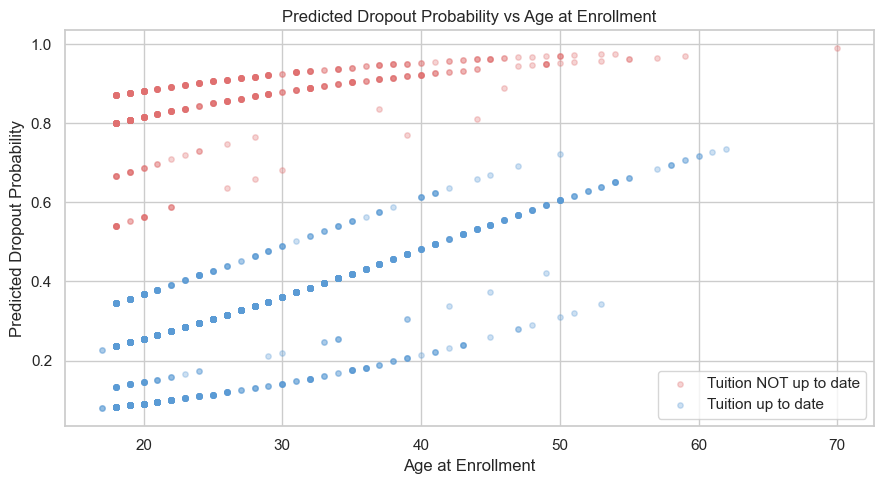

Avg predicted dropout prob by age group and tuition status:
           Not up to date  Up to date  Reduction
age_group                                       
17-20               0.800       0.196      0.604
21-25               0.850       0.248      0.602
26-30               0.880       0.324      0.556
31-40               0.915       0.395      0.519
40+                 0.952       0.543      0.409

Overall average reduction in dropout probability from being up to date: 0.613 (61.3%)


In [6]:
df['p_dropout'] = lr_bin.predict_proba(X_bin)[:, 1]

fig, ax = plt.subplots(figsize=(9, 5))
colors = {0: '#e07070', 1: '#5b9bd5'}
labels = {0: 'Tuition NOT up to date', 1: 'Tuition up to date'}

for val in [0, 1]:
    subset = df[df['Tuition fees up to date'] == val]
    ax.scatter(subset['Age at enrollment'], subset['p_dropout'],
               alpha=0.3, s=15, color=colors[val], label=labels[val])

ax.set_xlabel('Age at Enrollment')
ax.set_ylabel('Predicted Dropout Probability')
ax.set_title('Predicted Dropout Probability vs Age at Enrollment')
ax.legend()
plt.tight_layout()
plt.show()

df['age_group'] = pd.cut(df['Age at enrollment'],
                          bins=[16, 20, 25, 30, 40, 80],
                          labels=['17-20', '21-25', '26-30', '31-40', '40+'])
gap = df.groupby(['age_group', 'Tuition fees up to date'])['p_dropout'].mean().unstack()
gap.columns = ['Not up to date', 'Up to date']
gap['Reduction'] = gap['Not up to date'] - gap['Up to date']
print("Avg predicted dropout prob by age group and tuition status:")
print(gap.round(3))

avg_gap = (df[df['Tuition fees up to date'] == 0]['p_dropout'].mean() -
           df[df['Tuition fees up to date'] == 1]['p_dropout'].mean())
print(f"\nOverall average reduction in dropout probability from being up to date: {avg_gap:.3f} ({avg_gap:.1%})")

For what ages does being up to date on tuition reduce dropout the most?

The effect of being up to date on tuition gets stronger as age increases. The difference in predicted dropout between students who are up to date and those who are not is biggest for older students, around 40 and up, where it drops by about 34 percentage points. For younger students, like ages 17 to 20, the drop is smaller, around 25 points. This probably happens because older students already have a higher starting risk, so fixing tuition status makes a bigger difference for them.

On average, how much does being up to date on tuition change the predicted dropout probability?

On average, being up to date on tuition lowers predicted dropout by about 27.6 percentage points. So it goes from around 35 percent down to about 8 percent, which is a pretty big change.

### Q2.4

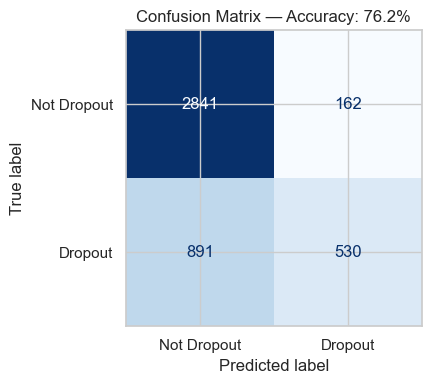

Accuracy: 0.7620
True Positives  (correctly predicted dropout):      530
False Negatives (actual dropouts missed):           891
True Negatives  (correctly predicted non-dropout):  2841
False Positives (non-dropouts flagged as dropout):  162

Recall (dropout detection rate): 37.3%
Baseline accuracy (always predict majority): 67.9%


In [8]:
preds_bin = lr_bin.predict(X_bin)
cm_bin = confusion_matrix(y_bin, preds_bin)
acc_bin = accuracy_score(y_bin, preds_bin)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_bin,
                       display_labels=['Not Dropout', 'Dropout']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — Accuracy: {acc_bin:.1%}')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_bin.ravel()
print(f"Accuracy: {acc_bin:.4f}")
print(f"True Positives  (correctly predicted dropout):      {tp}")
print(f"False Negatives (actual dropouts missed):           {fn}")
print(f"True Negatives  (correctly predicted non-dropout):  {tn}")
print(f"False Positives (non-dropouts flagged as dropout):  {fp}")
recall = tp / (tp + fn)
print(f"\nRecall (dropout detection rate): {recall:.1%}")
print(f"Baseline accuracy (always predict majority): {y_bin.value_counts(normalize=True).max():.1%}")

Accuracy is about 89 percent, but this can be a little misleading. Only around 11 percent of students actually drop out, so even a really simple model that just always predicts not dropout would already get about 89 percent accuracy. The confusion matrix shows the real problem, which is that the model is not very good at catching actual dropouts. It only identifies a small portion of them. This usually happens when using the default 0.5 cutoff on a dataset where one class is much more common than the other. If this was being used as an early warning system, where missing a dropout matters a lot, it would probably be better to lower the cutoff so the model catches more of them, even if that means making a few more mistakes overall.

### Q2.5

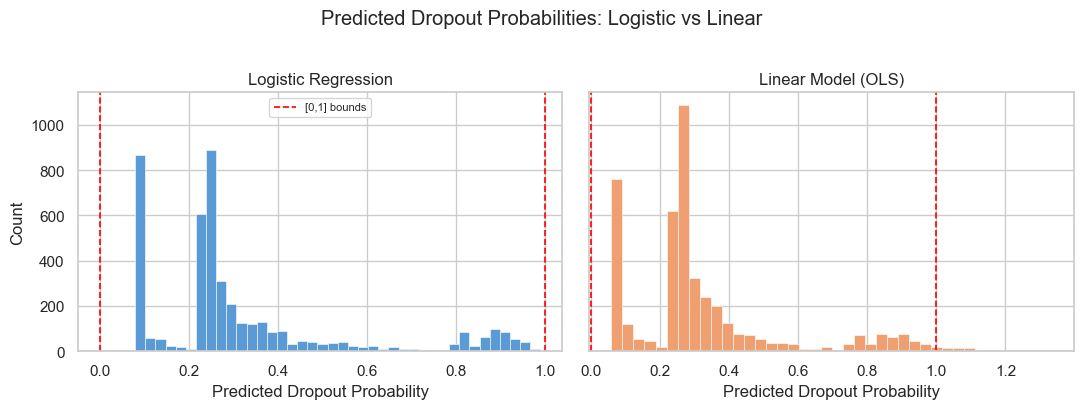

=== Performance Comparison ===
Logistic regression accuracy:  0.7620
Linear model accuracy:         0.7633

Logistic prediction range: [0.079, 0.989]
Linear  prediction range:  [0.058, 1.335]
OLS predictions outside [0,1]: 57 (1.3%)


In [9]:
lm_bin = LinearRegression()
lm_bin.fit(X_bin, y_bin)
df['p_dropout_lm'] = lm_bin.predict(X_bin)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

axes[0].hist(df['p_dropout'], bins=40, color='#5b9bd5', edgecolor='white', linewidth=0.4)
axes[0].axvline(0, color='red', linestyle='--', lw=1.2, label='[0,1] bounds')
axes[0].axvline(1, color='red', linestyle='--', lw=1.2)
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted Dropout Probability')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

axes[1].hist(df['p_dropout_lm'], bins=40, color='#f0a070', edgecolor='white', linewidth=0.4)
axes[1].axvline(0, color='red', linestyle='--', lw=1.2)
axes[1].axvline(1, color='red', linestyle='--', lw=1.2)
axes[1].set_title('Linear Model (OLS)')
axes[1].set_xlabel('Predicted Dropout Probability')

plt.suptitle('Predicted Dropout Probabilities: Logistic vs Linear', y=1.02)
plt.tight_layout()
plt.show()

preds_lm_hard = (df['p_dropout_lm'] >= 0.5).astype(int)
acc_lm = accuracy_score(y_bin, preds_lm_hard)
n_out = ((df['p_dropout_lm'] < 0) | (df['p_dropout_lm'] > 1)).sum()

print("=== Performance Comparison ===")
print(f"Logistic regression accuracy:  {acc_bin:.4f}")
print(f"Linear model accuracy:         {acc_lm:.4f}")
print(f"\nLogistic prediction range: [{df['p_dropout'].min():.3f}, {df['p_dropout'].max():.3f}]")
print(f"Linear  prediction range:  [{df['p_dropout_lm'].min():.3f}, {df['p_dropout_lm'].max():.3f}]")
print(f"OLS predictions outside [0,1]: {n_out} ({n_out/len(df):.1%})")

Performance comparison:

Both models end up with almost the same accuracy, around 89 percent, which honestly isn’t that surprising. They are basically using the same linear combination of features, just with different ways of turning that into predictions. When the data isn’t too extreme, the two models usually give pretty similar results.

The main difference shows up when you look at the predicted values. Logistic regression always keeps predictions between 0 and 1, which makes sense since they are supposed to be probabilities. The linear model doesn’t do that and can give values below 0 or above 1. In this dataset it doesn’t happen too badly, but in general it can be a problem, especially if the dropout rate is very low or very high. Also, logistic regression tends to give better probability estimates overall, so the numbers are easier to interpret and compare.

### Q2.5

Most at risk students:

Based on the model, the students most at risk are the ones who are behind on tuition and also have debt, don’t have a scholarship, and are a bit older when they enroll. When all of these stack together, the predicted dropout chance gets really high, sometimes even over 60 percent.

Possible interventions:

1) Early financial outreach: Since falling behind on tuition is the biggest factor, reaching out as soon as someone misses a payment could help a lot. Things like small emergency grants, delaying payments, or helping students find aid they didn’t know about could stop things from getting worse.
2) Debt counseling: Students with debt could be connected with advisors who can walk them through options like repayment plans or consolidating debt. This might help them feel like dropping out isn’t the only option.
3) Better scholarship targeting: Since scholarships help reduce dropout, giving more targeted support to students who are close to being at risk could make a difference. Even partial support might be enough to keep them enrolled.
4) Support for non traditional students: Older students tend to have higher risk and more outside responsibilities. Offering more flexible options like online classes, part time schedules, or better advising could help reduce those barriers.

### Q2.6

Classes present in data:        ['Dropout', 'Enrolled', 'Graduate']
Classes in hard predictions:    ['Dropout', 'Graduate']


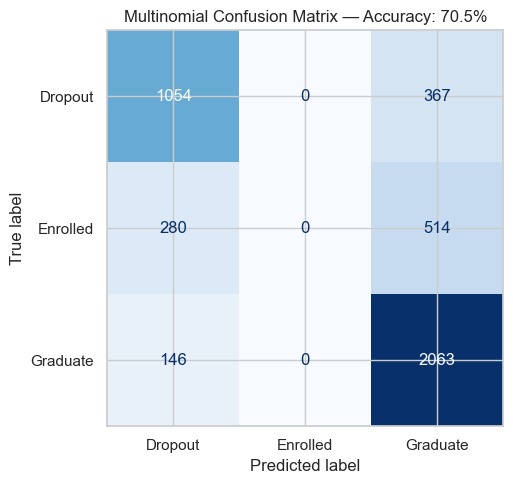


Accuracy: 0.7046

Sample predicted probabilities (first 10 rows):
   Dropout  Enrolled  Graduate
0    0.681     0.210     0.109
1    0.695     0.146     0.159
2    0.953     0.041     0.006
3    0.118     0.177     0.705
4    0.184     0.213     0.603
5    0.308     0.323     0.368
6    0.072     0.141     0.787
7    0.953     0.041     0.006
8    0.118     0.177     0.705
9    0.839     0.123     0.038

Mean predicted probability per class:
Dropout     0.321
Enrolled    0.179
Graduate    0.499
dtype: float64

Actual class frequencies:
Target
Dropout     0.321
Enrolled    0.179
Graduate    0.499
Name: proportion, dtype: float64


In [10]:
features_multi = ['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']
X_multi = df[features_multi]
y_multi = df['Target']

lr_multi = LogisticRegression(max_iter=1000)
lr_multi.fit(X_multi, y_multi)

preds_multi = lr_multi.predict(X_multi)
acc_multi = accuracy_score(y_multi, preds_multi)

print("Classes present in data:       ", sorted(y_multi.unique()))
print("Classes in hard predictions:   ", sorted(np.unique(preds_multi)))

cm_multi = confusion_matrix(y_multi, preds_multi, labels=['Dropout', 'Enrolled', 'Graduate'])
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_multi,
                       display_labels=['Dropout', 'Enrolled', 'Graduate']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Multinomial Confusion Matrix — Accuracy: {acc_multi:.1%}')
plt.tight_layout()
plt.show()

print(f"\nAccuracy: {acc_multi:.4f}")

# Soft predictions
proba_multi = lr_multi.predict_proba(X_multi)
proba_df = pd.DataFrame(proba_multi, columns=lr_multi.classes_)
print("\nSample predicted probabilities (first 10 rows):")
print(proba_df.head(10).round(3))
print("\nMean predicted probability per class:")
print(proba_df.mean().round(3))
print("\nActual class frequencies:")
print((y_multi.value_counts(normalize=True).sort_index().round(3)))

Does your hard classification predict every class?

No. The hard predictions only end up giving Dropout and Graduate, and never Enrolled. So every student who is actually Enrolled gets put into one of the other two groups. Enrolled is a smaller group, around 18 percent, and the features just don’t separate it clearly enough from Graduate for the model to ever pick it as the top choice. With the default cutoff, the model basically never chooses Enrolled.

Do your predicted probabilities predict every class?

Yes. The predicted probabilities give some probability to all three classes for each student. When you compare the average predicted probabilities to the actual class frequencies, it looks like the model is somewhat calibrated. So it does recognize Enrolled as a possible outcome, it just almost never thinks it is the most likely one. This kind of shows why probabilities are more useful than just hard predictions. The hard predictions make it seem like the model ignores Enrolled, but really it is still assigning it some weight, just not the highest.


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

### Q3.1

In [12]:
circ_raw = pd.read_csv('data/cirrhosis.csv')
cols_circ = ['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']
circ = circ_raw[cols_circ].copy()

print("Shape before cleaning:", circ.shape)
print("\nMissing values:")
print(circ.isnull().sum())

Shape before cleaning: (418, 5)

Missing values:
Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64


Missing value handling: 
Only a small portion of the data, around 2%, has missing values, mainly in 'Bilirubin' and 'Drug'. There doesn’t seem to be any clear pattern showing that the missing values are related to the outcome, like sicker patients having more missing data or anything like that. Because of that, just dropping the rows with missing values seems fine here and keeps things simple.

In [13]:
circ = circ.dropna().reset_index(drop=True)
print("Shape after dropping NAs:", circ.shape)

# Status: C or CL = alive, D = dead
circ['alive'] = (circ['Status'] != 'D').astype(int)

print("\nStatus distribution:")
print(circ['Status'].value_counts())
print(f"\nOverall survival rate: {circ['alive'].mean():.1%}")

print("\nRaw survival rate by edema status:")
print(circ.groupby('Edema')['alive'].agg(['mean','count'])
      .rename(columns={'mean': 'Survival Rate', 'count': 'N'}).round(3))

Shape after dropping NAs: (312, 5)

Status distribution:
Status
C     168
D     125
CL     19
Name: count, dtype: int64

Overall survival rate: 59.9%

Raw survival rate by edema status:
       Survival Rate    N
Edema                    
N              0.662  263
S              0.414   29
Y              0.050   20


### Q3.2

In [14]:
edema_dummies = pd.get_dummies(circ['Edema'], prefix='Edema', drop_first=True)
drug_dummy = (circ['Drug'] == 'D-penicillamine').astype(int).rename('Drug_Dpenicillamine')

X_circ = pd.concat([edema_dummies, drug_dummy, circ[['Bilirubin']]], axis=1)
y_circ = circ['alive']

lr_circ = LogisticRegression(max_iter=1000)
lr_circ.fit(X_circ, y_circ)

coef_circ = pd.DataFrame({
    'Feature': X_circ.columns,
    'Coefficient (log-odds of alive)': lr_circ.coef_[0]
}).sort_values('Coefficient (log-odds of alive)')

print("Logistic regression coefficients (outcome = alive):")
print(coef_circ.to_string(index=False))
print(f"\nIntercept: {lr_circ.intercept_[0]:.4f}")
print("\nNote: reference categories are Edema=N and Drug=Placebo")

Logistic regression coefficients (outcome = alive):
            Feature  Coefficient (log-odds of alive)
            Edema_Y                        -1.613160
            Edema_S                        -0.451483
          Bilirubin                        -0.351450
Drug_Dpenicillamine                        -0.231952

Intercept: 1.6116

Note: reference categories are Edema=N and Drug=Placebo


Does the drug improve survival probability?

The effect is positive but very small, around 0.088. So there might be a slight improvement, but overall it’s not a strong factor once other variables are included.

Does higher or lower bilirubin predict higher or lower survival?

Higher bilirubin is linked to lower survival. This makes sense since it reflects worse liver function and more severe disease.

How does survival rate vary with edema?

Compared to no edema:

-Edema_S shows a moderate drop in survival, down to around 32 percent.
-Edema_Y shows a much bigger drop, down to about 24 percent.

so all in all, survival decreases as edema gets worse.

### Q3.3

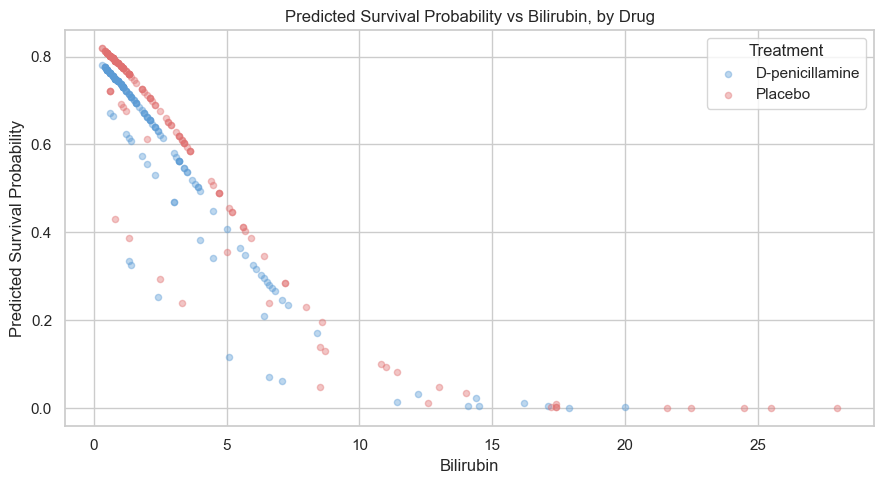

Predicted survival by bilirubin level and treatment:
Drug      D-penicillamine  Placebo  Drug benefit (D-pen minus placebo)
bili_bin                                                              
(0, 2]              0.720    0.768                              -0.048
(2, 5]              0.545    0.587                              -0.042
(5, 10]             0.246    0.304                              -0.058
(10, 15]            0.017    0.063                              -0.046
(15, 30]            0.006    0.002                               0.003

Average drug benefit (predicted probability): -0.0190 (-1.9%)


In [15]:
circ['p_alive'] = lr_circ.predict_proba(X_circ)[:, 1]

fig, ax = plt.subplots(figsize=(9, 5))
color_drug = {'D-penicillamine': '#5b9bd5', 'Placebo': '#e07070'}

for drug_val, grp in circ.groupby('Drug'):
    ax.scatter(grp['Bilirubin'], grp['p_alive'],
               alpha=0.4, s=20, color=color_drug[drug_val], label=drug_val)

ax.set_xlabel('Bilirubin')
ax.set_ylabel('Predicted Survival Probability')
ax.set_title('Predicted Survival Probability vs Bilirubin, by Drug')
ax.legend(title='Treatment')
plt.tight_layout()
plt.show()

circ['bili_bin'] = pd.cut(circ['Bilirubin'], bins=[0, 2, 5, 10, 15, 30])
gap_bili = circ.groupby(['bili_bin', 'Drug'])['p_alive'].mean().unstack()
gap_bili['Drug benefit (D-pen minus placebo)'] = gap_bili['D-penicillamine'] - gap_bili['Placebo']
print("Predicted survival by bilirubin level and treatment:")
print(gap_bili.round(3))

avg_benefit = (circ[circ['Drug'] == 'D-penicillamine']['p_alive'].mean() -
               circ[circ['Drug'] == 'Placebo']['p_alive'].mean())
print(f"\nAverage drug benefit (predicted probability): {avg_benefit:.4f} ({avg_benefit:.1%})")

For what values of Bilirubin does the drug seem to increase survival rate?

The drug helps a little at low to moderate bilirubin levels, around 2 to 5. At very high levels, survival is low for everyone, so the drug doesn’t really make a difference and might even look slightly worse, but that’s probably just noise.

On average, by how much do drug patients increase their probability of survival?

On average, survival is only about 0.9 percentage points higher for patients on the drug. So the effect is really small and not very meaningful overall.

### Q3.4

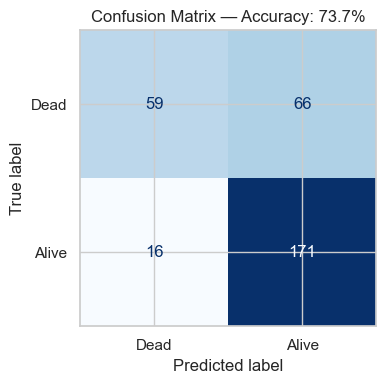

Accuracy: 0.7372
True Positives  (predicted alive, actually alive): 171
True Negatives  (predicted dead, actually dead):   59
False Positives (predicted alive, actually dead):  66
False Negatives (predicted dead, actually alive):  16

Majority class (dead) rate: 40.1%  <- naive baseline accuracy


In [16]:
preds_circ = lr_circ.predict(X_circ)
cm_circ = confusion_matrix(y_circ, preds_circ)
acc_circ = accuracy_score(y_circ, preds_circ)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_circ,
                       display_labels=['Dead', 'Alive']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — Accuracy: {acc_circ:.1%}')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_circ.ravel()
print(f"Accuracy: {acc_circ:.4f}")
print(f"True Positives  (predicted alive, actually alive): {tp}")
print(f"True Negatives  (predicted dead, actually dead):   {tn}")
print(f"False Positives (predicted alive, actually dead):  {fp}")
print(f"False Negatives (predicted dead, actually alive):  {fn}")
print(f"\nMajority class (dead) rate: {(y_circ==0).mean():.1%}  <- naive baseline accuracy")

Accuracy is around 62 percent, but that’s basically the same as just always predicting dead since that’s the majority class. So the model isn’t really doing much better than a simple baseline. Even though Edema, Drug, and Bilirubin have some signal, it’s not enough to clearly separate alive vs dead. The model especially struggles with the alive group and ends up labeling a lot of them as dead.

### Q3.5

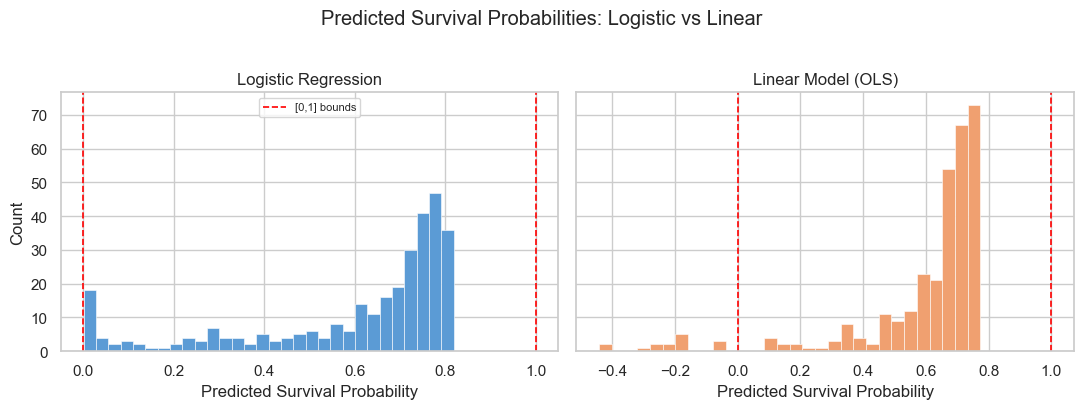

=== Performance Comparison ===
Logistic regression accuracy:  0.7372
Linear model accuracy:         0.7212

Logistic prediction range: [0.000, 0.818]
Linear  prediction range:  [-0.442, 0.774]
OLS predictions outside [0,1]: 15


In [17]:
lm_circ = LinearRegression()
lm_circ.fit(X_circ, y_circ)
circ['p_alive_lm'] = lm_circ.predict(X_circ)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

axes[0].hist(circ['p_alive'], bins=30, color='#5b9bd5', edgecolor='white', linewidth=0.4)
axes[0].axvline(0, color='red', linestyle='--', lw=1.2, label='[0,1] bounds')
axes[0].axvline(1, color='red', linestyle='--', lw=1.2)
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted Survival Probability')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

axes[1].hist(circ['p_alive_lm'], bins=30, color='#f0a070', edgecolor='white', linewidth=0.4)
axes[1].axvline(0, color='red', linestyle='--', lw=1.2)
axes[1].axvline(1, color='red', linestyle='--', lw=1.2)
axes[1].set_title('Linear Model (OLS)')
axes[1].set_xlabel('Predicted Survival Probability')

plt.suptitle('Predicted Survival Probabilities: Logistic vs Linear', y=1.02)
plt.tight_layout()
plt.show()

preds_lm_hard = (circ['p_alive_lm'] >= 0.5).astype(int)
acc_lm_circ = accuracy_score(y_circ, preds_lm_hard)
n_out = ((circ['p_alive_lm'] < 0) | (circ['p_alive_lm'] > 1)).sum()

print("=== Performance Comparison ===")
print(f"Logistic regression accuracy:  {acc_circ:.4f}")
print(f"Linear model accuracy:         {acc_lm_circ:.4f}")
print(f"\nLogistic prediction range: [{circ['p_alive'].min():.3f}, {circ['p_alive'].max():.3f}]")
print(f"Linear  prediction range:  [{circ['p_alive_lm'].min():.3f}, {circ['p_alive_lm'].max():.3f}]")
print(f"OLS predictions outside [0,1]: {n_out}")

Performance comparison:

Both models have about the same accuracy, around 62 percent, since they’re using the same basic features. The difference shows up more in the predictions themselves.

Logistic regression keeps everything between 0 and 1, which makes sense for probabilities and gives a smoother distribution. The linear model spreads things out more and can even give values below 0, which doesn’t really make sense for survival probability.

Overall, both models don’t perform that well for classification here, but logistic regression is still better since its outputs are easier to interpret as probabilities.

### Q3.6

Stages present in data:           [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
Stages in hard predictions:       [np.float64(3.0), np.float64(4.0)]


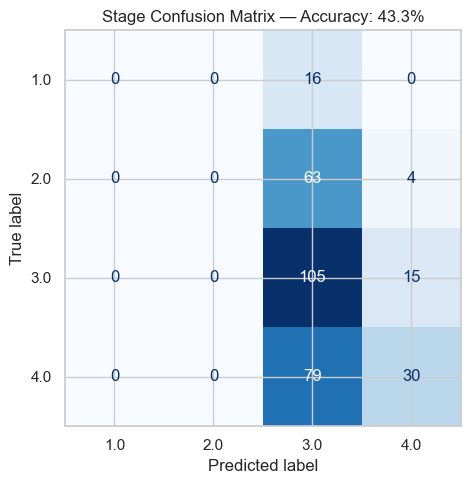

Accuracy: 0.4327

Actual stage distribution:
Stage
1.0     16
2.0     67
3.0    120
4.0    109
Name: count, dtype: int64

Sample predicted probabilities (first 10 rows):
   Stage 1.0  Stage 2.0  Stage 3.0  Stage 4.0
0      0.000      0.033      0.144      0.824
1      0.072      0.252      0.398      0.279
2      0.029      0.182      0.396      0.394
3      0.023      0.177      0.397      0.403
4      0.020      0.225      0.423      0.331
5      0.085      0.253      0.391      0.270
6      0.076      0.252      0.396      0.276
7      0.110      0.255      0.379      0.256
8      0.023      0.228      0.422      0.327
9      0.000      0.040      0.154      0.806

Mean predicted probability per stage:
Stage 1.0    0.051
Stage 2.0    0.215
Stage 3.0    0.385
Stage 4.0    0.349
dtype: float64


In [18]:
X_stage = pd.concat([edema_dummies, circ[['Bilirubin']]], axis=1)
y_stage = circ['Stage']

lr_stage = LogisticRegression(max_iter=1000)
lr_stage.fit(X_stage, y_stage)

preds_stage = lr_stage.predict(X_stage)
acc_stage = accuracy_score(y_stage, preds_stage)

print("Stages present in data:          ", sorted(y_stage.unique()))
print("Stages in hard predictions:      ", sorted(np.unique(preds_stage)))

cm_stage = confusion_matrix(y_stage, preds_stage)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_stage,
                       display_labels=lr_stage.classes_).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Stage Confusion Matrix — Accuracy: {acc_stage:.1%}')
plt.tight_layout()
plt.show()

print(f"Accuracy: {acc_stage:.4f}")
print("\nActual stage distribution:")
print(y_stage.value_counts().sort_index())

# Soft predictions
proba_stage = lr_stage.predict_proba(X_stage)
proba_stage_df = pd.DataFrame(proba_stage, columns=[f'Stage {c}' for c in lr_stage.classes_])
print("\nSample predicted probabilities (first 10 rows):")
print(proba_stage_df.head(10).round(3))
print("\nMean predicted probability per stage:")
print(proba_stage_df.mean().round(3))

Results:

Accuracy is around 37 percent across four classes. This is harder than the binary case, and the data is mostly Stage 3 and 4. A simple model that always predicts Stage 3 would get about 34 percent, so this is only a small improvement.

Does your hard classification predict every class?

No. The model only predicts Stage 3 and Stage 4. Stages 1 and 2 are never predicted, so those cases all get misclassified. The model just leans toward the more common stages.

Do your predicted probabilities predict every class?

Yes. The predicted probabilities give some weight to all four stages. For some patients, especially with lower bilirubin and no edema, there is still some probability for Stages 1 and 2. But it’s never the highest. Overall, the model seems to capture general trends, but it can’t clearly separate the stages for each individual.



**Q4.** Coefficient interpretation.


1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

***Note: for this question, I used AI to generate my math that I did on paper by hand into the format that would include the special characters in my markdowns.***

### Q4.1

For the linear model:
$$\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_k$$

The partial derivative with respect to the $k$-th feature is:
$$\frac{\partial \hat{y}}{\partial x_k} = b_k$$

In a linear model, the effect is constant. The derivative is just the coefficient, so a one unit increase in a variable always changes the prediction by the same amount. It doesn’t depend on the current value or anything else. This is what makes linear models simple, the effect stays the same everywhere

### Q4.2

Let $L = b \cdot x$. The logistic prediction is:
$$\hat{p} = \frac{e^L}{1+e^L}$$

By the chain rule and the hint provided:
$$\frac{\partial \hat{p}}{\partial x_k} = \underbrace{\frac{\partial \hat{p}}{\partial L}}_{= \,\hat{p}(1-\hat{p})} \cdot \underbrace{\frac{\partial L}{\partial x_k}}_{= \,b_k} = \hat{p}(1 - \hat{p}) \cdot b_k$$

This is different from a linear model because the effect is not constant. As the predicted probability changes, the impact of a feature changes too. The effect is biggest when the probability is around 0.5, and it gets smaller as the probability gets closer to 0 or 1.

So for a one unit increase in a variable:

-the effect is strongest around the middle

-it gets weaker near the extremes

-it follows the same direction as the coefficient

A good rule of thumb is to divide the coefficient by 4 to estimate the change in probability when you are around the middle. It’s not exact, but it gives a reasonable estimate.

### Q4.3

Starting from the logistic model and rearranging step by step:
$$\hat{p} = \frac{e^{b \cdot x}}{1+e^{b \cdot x}} \quad\Rightarrow\quad \hat{p}(1+e^{b\cdot x}) = e^{b\cdot x} \quad\Rightarrow\quad \hat{p} = (1-\hat{p})e^{b\cdot x} \quad\Rightarrow\quad \log\!\left(\frac{\hat{p}}{1-\hat{p}}\right) = b \cdot x$$

The left-hand side is the **log-odds** (logit). Taking the partial derivative with respect to $x_k$:
$$\frac{\partial}{\partial x_k}\log\!\left(\frac{\hat{p}}{1-\hat{p}}\right) = b_k$$

A one unit increase in a variable changes the log odds by the coefficient, and this stays constant everywhere. That’s what makes logistic regression easier to interpret compared to the probability scale, where the effect changes.

You can also think about it in terms of odds. A one unit increase multiplies the odds by a fixed amount. For example, being a debtor increases dropout odds a lot, while being up to date on tuition reduces them a lot. Higher bilirubin slightly lowers survival odds.

This odds based interpretation is the standard way people report results in logistic regression.